# Table of Contents
- Backpropagation
- Vanishing and Exploding Gradients
- Batch Normalization Layer
- Drop Out
- ANN Fashion MNIST Classification


# Backpropagation

### **📢 Checkout the Backpropation slide and class for more**


![](https://miro.medium.com/1*M8iBhtIFI0GuYNw8AUzHEQ.png)


# Vanishing and Exploding Gradients

### The Core Concept: The Chain Rule
In a neural network, learning happens by calculating how much each weight contributed to the error. For a deep network, this requires multiplying many numbers together.

$$
\frac{\partial Loss}{\partial w_1} = \frac{\partial Loss}{\partial a_4} \cdot \frac{\partial a_4}{\partial a_3} \cdot \frac{\partial a_3}{\partial a_2} \cdot \frac{\partial a_2}{\partial w_1}
$$


---

### 1. Vanishing Gradients

#### What is it?
The gradient gets smaller and smaller at each step until it effectively becomes zero. By the time it reaches the early layers ($w_1$), there is no signal left to tell those weights how to update. The early layers stop learning entirely.

#### Why it happens
-   **Saturating Activation Functions:** Functions like Sigmoid squash outputs between 0 and 1. Their derivative ($\sigma'$) is always $\leq 0.25$. Multiplying numbers $< 1$ repeatedly makes the result shrink exponentially.
-   **Too Many Layers:** More terms in the chain rule product means more opportunities for the value to shrink.
-   **Small Weight Initialization:** If weights start too small, the derivatives involving those weights are also small, compounding the problem.

#### Common Symptoms
-   Training loss stops decreasing (plateaus) very early.
-   Weights in the first few layers never change from their initial values.
-   Later layers train normally while early layers remain "frozen."

#### Numerical Example
Imagine a 4-layer network where each intermediate derivative averages **0.2** (typical for Sigmoid):

$$
\frac{\partial Loss}{\partial w_1} \approx 1.0 \times 0.2 \times 0.2 \times 0.2 = 0.008
$$

Now imagine a 10-layer network with the same 0.2 factor:
$$
0.2^9 \approx 0.000000512
$$
This number is so small that when multiplied by a learning rate (e.g., 0.01), the weight update becomes negligible. $w_1$ effectively stops learning.

#### Common Solutions
-   **Use ReLU Activation:** Its derivative is exactly **1** for positive inputs, so it doesn't shrink the gradient.
-   **Residual Connections (Skip Connections):** Add a shortcut path where the gradient can flow backward without being multiplied, preserving the signal.
-   **Better Initialization:** Use He or Xavier initialization to keep initial derivatives closer to 1.
-   **Batch Normalization:** Prevents activations from entering the saturated regions of Sigmoid/Tanh.

---

### 2. Exploding Gradients

#### What is it?
The opposite problem. The gradients gets larger and larger at each step. By the time it reaches $w_1$, the gradient is astronomically huge. This causes massive, destructive weight updates that break the model.

#### Why it happens
-   **Large Weights:** If weights are initialized too large or grow unchecked, the derivatives involving them exceed 1. Multiplying numbers $> 1$ repeatedly causes exponential growth.
-   **No Gradient Control:** Without clipping or normalization, there is nothing to cap the growing signal.
-   **Recurrent Networks (RNNs):** The same weight matrix is multiplied over and over across timesteps. If its largest eigenvalue > 1, gradients explode quickly.
-   **High Learning Rate:** Amplifies an already-large gradient into a catastrophic update.

#### Common Symptoms
-   Loss suddenly becomes `NaN` or `Infinity`.
-   Gradient norms spike to extremely large values (e.g., $10^6+$).
-   Model weights oscillate wildly or become enormous.
-   Training was going well, then suddenly diverges.

#### Numerical Example
Imagine a 4-layer network where poor initialization causes each intermediate derivative to average **2.0**:

$$
\frac{\partial Loss}{\partial w_1} \approx 1.0 \times 2.0 \times 2.0 \times 2.0 = 8.0
$$

Now a 10-layer network with the same 2.0 factor:
$$
2.0^9 = 512
$$
With a learning rate of 0.01, the weight update would be $512 \times 0.01 = 5.12$. This is a massive jump that will likely overshoot any minimum and destabilize training. At 30 layers, $2^{29} \approx 5 \times 10^8$, which causes immediate numerical overflow.

#### Common Solutions
-   **Gradient Clipping:** Before updating weights, cap the gradient norm to a maximum threshold (e.g., 1.0 or 5.0). This is the most direct fix.
-   **Proper Weight Initialization:** Xavier/He initialization ensures starting derivatives stay near 1.
-   **Lower Learning Rate / Warmup:** Start with a tiny learning rate and gradually increase it to avoid early explosions.
-   **Batch/Layer Normalization:** Keeps activation magnitudes stable, preventing runaway growth.
-   **L2 Regularization:** Penalizes large weights, indirectly preventing the conditions that cause explosion.

---

### Vanishing vs Exploding Gradients

| Aspect             | Vanishing Gradient                              | Exploding Gradient                                      |
| ------------------ | ----------------------------------------------- | ------------------------------------------------------- |
| Gradient behavior  | Becomes very small                              | Becomes very large                                      |
| Mathematical cause | Repeated multiplication of values < 1           | Repeated multiplication of values > 1                   |
| Effect on learning | Early layers learn very slowly or stop learning | Training becomes unstable                               |
| Weight updates     | Tiny updates (almost no change)                 | Huge updates (overshooting)                             |
| Loss behavior      | Decreases very slowly or plateaus               | Fluctuates wildly or becomes NaN                        |
| Common in          | Deep networks with sigmoid/tanh                 | Deep networks with large weights or poor initialization |
| Typical symptoms   | Model stops improving early                     | Loss spikes or diverges                                 |
| Root intuition     | Gradients “shrink” through chain rule           | Gradients “amplify” through chain rule                  |
| Extreme outcome    | Underfitting                                    | Divergence / numerical overflow                         |
| Fixes              | ReLU, better initialization, residuals          | Gradient clipping, better initialization, normalization |



# Batch Normalization in Neural Networks

**Batch Normalization (BatchNorm)** is a layer used to **stabilize and speed up training** by normalizing activations inside a neural network.

It was introduced to reduce problems like **vanishing/exploding gradients** and make training deep networks much more reliable.

![](https://images.deepai.org/glossary-terms/981e1ffea3814ae193c27461253faf63/batch_normalization.png)

---

## Core Idea

During training, the inputs to each layer can keep changing as earlier layers update. This is called **internal covariate shift**.

BatchNorm fixes this by making layer inputs:

> **zero mean and unit variance (per batch)**

---

## Mathematical Form

For a batch activation (x):

#### Step 1: Compute mean and variance

$
\mu_B = \frac{1}{m} \sum_{i=1}^{m} x_i
$

$
\sigma_B^2 = \frac{1}{m} \sum_{i=1}^{m} (x_i - \mu_B)^2
$

---

#### Step 2: Normalize

$
\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}}
$

---

#### Step 3: Scale and shift (learnable)

$
y_i = \gamma \hat{x}_i + \beta
$

* $( \gamma )$ → scale parameter (learned)
* $( \beta )$ → shift parameter (learned)

---

## Where it is used?

BatchNorm is applied:

* After linear layer / convolution
* Before or after activation (commonly before activation in modern architectures)

Example:

```
Linear → BatchNorm → ReLU
```

---

## Why BatchNorm works?

### 1. Reduces exploding/vanishing gradients

By keeping activations in a controlled range.

### 2. Stabilizes training

Gradients become smoother and more predictable.

### 3. Allows higher learning rates

Because training is more stable.

### 4. Acts as regularization

Adds slight noise due to batch statistics → reduces overfitting.

---

## Intuition

Without BatchNorm:

```
Layer outputs → can become very large or very small → unstable gradients
```

With BatchNorm:

```
Outputs → normalized → consistent scale → stable gradients
```

---

## Effect on Gradient Flow

BatchNorm helps keep:

* gradients **not too small** (fix vanishing)
* gradients **not too large** (fix exploding)

So it improves:

> **gradient flow through deep networks**

---


# Drop Out in Neural Network

Dropout is a regularization technique used to reduce overfitting in neural networks by randomly `turning off` some neurons during training.

![](https://www.researchgate.net/profile/Amine-Ben-Khalifa/publication/309206911/figure/fig3/AS:418379505651712@1476760855735/Dropout-neural-network-model-a-is-a-standard-neural-network-b-is-the-same-network.png)

Dropout = randomly switching off neurons during training so the model learns more robustly and avoids overfitting.

# 👔 Fashion Product Classification using Artificial Neural Network

![](https://www.researchgate.net/profile/Saeed-Reza-Kheradpisheh/publication/342801790/figure/fig2/AS:911232181735425@1594266090934/Sample-images-from-Fashion-MNIST-dataset.png)

In [2]:
!pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable
  Using cached tensorflow-2.21.0-cp311-cp311-win_amd64.whl.metadata (4.5 kB)
  Using cached absl_py-2.4.0-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.12.19-py2.py3-none-any.whl.metadata (1.0 kB)
  Using cached gast-0.7.0-py3-none-any.whl.metadata (1.5 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-py2.py3-none-win_amd64.whl.metadata (5.3 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.3.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached h5py-3.14.0-cp311-cp311-win_amd64.whl.metadata (2.7 kB)
  Using cached ml_dtypes-0.5.4-cp311-cp311-win_amd64.whl.metadata (9.2 kB)
  Using cached wheel-0.47.0-py3-none-any.whl.metadata (2.3 kB)
  Using cached rich-15.0.0-py3-none-any.whl.metadata (18 kB)
  Using cached namex-0.


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 📦 1. Import Libraries

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models

import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report, confusion_matrix

## 📥 2. Load Fashion MNIST Dataset

In [4]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

print(x_train.shape)  # (60000, 28, 28)
print(y_train.shape)

print(x_test.shape)  # (10000, 28, 28)
print(y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(60000, 28, 28)
(60000,)
(10000, 28, 28)
(10000,)


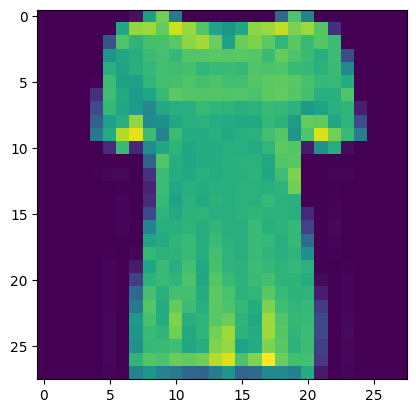

In [6]:
x_train[10]
plt.imshow(x_train[10])

In [8]:
print(y_train[10])

0


In [ ]:
# Label mapper

idx_to_label = {
    0: "T-shirt/top",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle boot"
}

## 🎨 3. Visualization of Sample Data

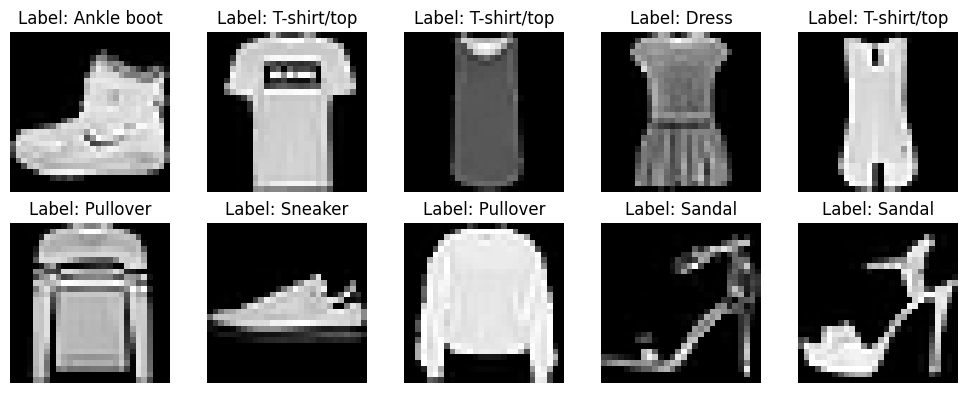

In [ ]:
plt.figure(figsize=(10, 4))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_train[i], cmap='gray')
    plt.title(f"Label: {idx_to_label[y_train[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Data Preprocessing (Flatten + Normalize)

![](https://lh3.googleusercontent.com/proxy/wNLhUqpOpBGPmfUIopgsshTtyJHh8VnAl5Ef4Koz9vXhLQ5osTQBwi5dTV-SbeL7NV6mRN_bOM8OO2bFL8Np3AQQTjdKm3Qb5MNhmB3Ts0E954BJJl-cjHp5f1c6znVIahNpuA)

![](https://www.superdatascience.com/wp-content/uploads/73_blog_image_1.png)

In [ ]:
print(f"Train data shape before flattening: {x_train.shape}")
print(f"Test data shape before flatteing: {x_test.shape}")

x_train = x_train.reshape(60000, 28*28)
x_test = x_test.reshape(10000, 28*28)

print(f"Train data shape after flattening: {x_train.shape}")
print(f"Test data shape after flatteing: {x_test.shape}")

Train data shape before flattening: (60000, 28, 28)
Test data shape before flatteing: (10000, 28, 28)
Train data shape after flattening: (60000, 784)
Test data shape after flatteing: (10000, 784)


In [ ]:
print(f"Max pixel value before Normalization: {x_train.max()}")
print(f"Min pixel value before Normalization: {x_train.min()}")

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print(f"Max pixel value after Normalization: {x_train.max()}")
print(f"Min pixel value after Normalization: {x_train.min()}")

Max pixel value before Normalization: 255
Min pixel value before Normalization: 0
Max pixel value after Normalization: 1.0
Min pixel value after Normalization: 0.0


## 🏗️ 5. Build ANN Model

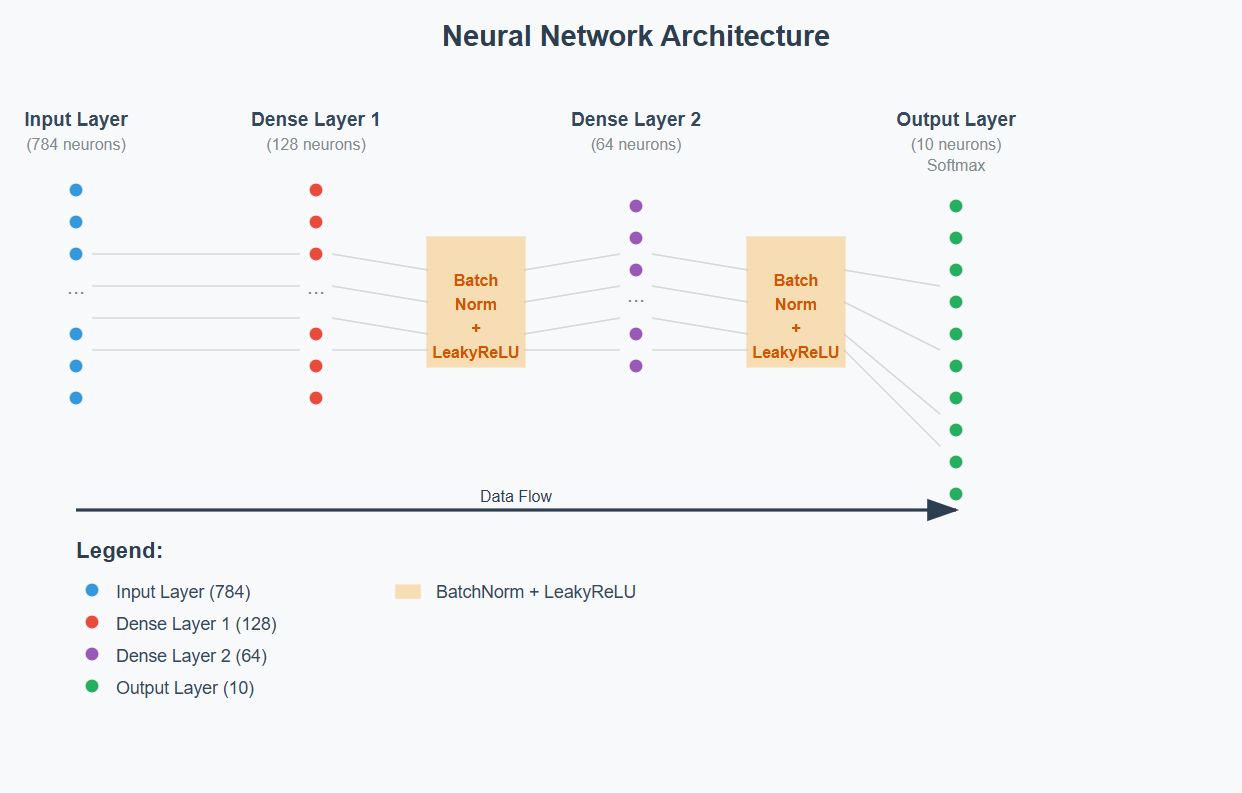

In [ ]:
model = models.Sequential([

    layers.Input(shape=(784,)),

    layers.Dense(128),
    layers.BatchNormalization(),
    layers.LeakyReLU(alpha=0.01),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.LeakyReLU(negative_slope=0.01),

    layers.Dense(10),
    layers.Softmax()

])

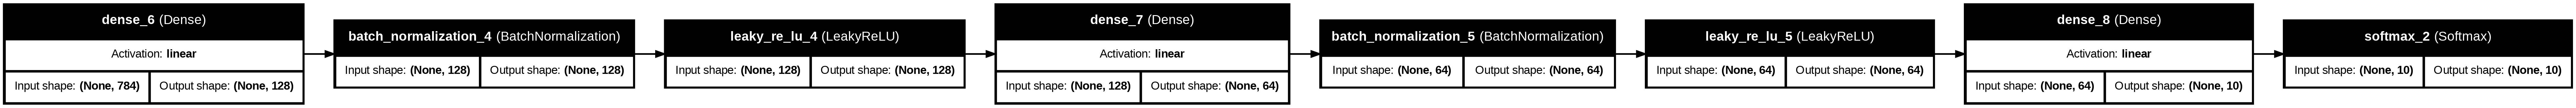

In [ ]:
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file='neural_network_plot.png',
    show_shapes=True,
    show_dtype=False,
    show_layer_names=True,
    rankdir='LR', # 'TB' for top-to-bottom layout; 'LR' for left-to-right layout
    show_layer_activations=True
)

## ⚙️ 6. Compile Model

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_4 (LeakyReLU)       │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_5 (LeakyReLU)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_2 (Softmax)             │ (None, 10)             │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,154 (430.29 KB)

 Trainable params: 109,770 (428.79 KB)

 Non-trainable params: 384 (1.50 KB)

## 🚀 7. Train Model

In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 7ms/step - accuracy: 0.8344 - loss: 0.4854 - val_accuracy: 0.8572 - val_loss: 0.3926
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8733 - loss: 0.3508 - val_accuracy: 0.8707 - val_loss: 0.3652
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8863 - loss: 0.3112 - val_accuracy: 0.8754 - val_loss: 0.3449
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - accuracy: 0.8942 - loss: 0.2839 - val_accuracy: 0.8680 - val_loss: 0.3673
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9024 - loss: 0.2635 - val_accuracy: 0.8643 - val_loss: 0.3697
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9082 - loss: 0.2481 - val_accuracy: 0.8817 - val_loss: 0.3368
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9135 - loss: 0.2365 - val_accuracy: 0.8739 - val_loss: 0.3579
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9172 - loss: 0.2206 - val_accuracy: 0.

## 📈 8. Training Visualization

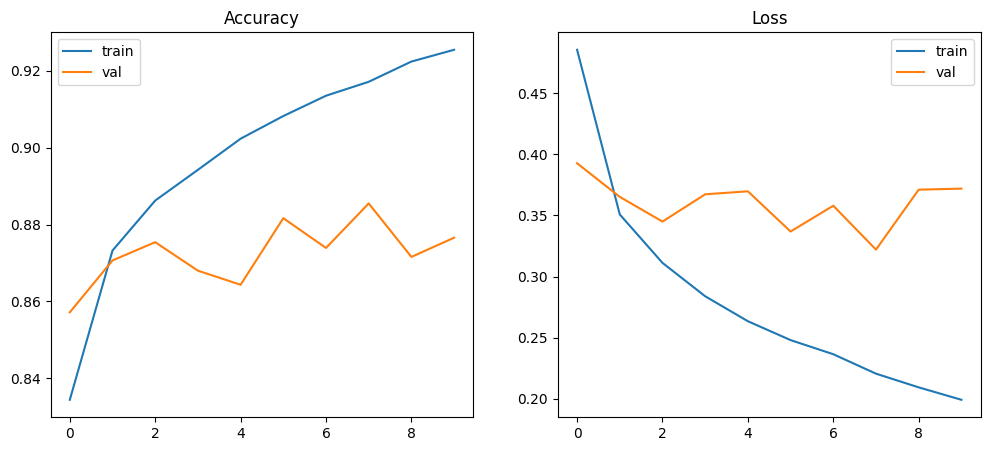

In [ ]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title("Accuracy")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title("Loss")
plt.legend()

plt.show()

## 🔮 9. Predictions Visualization

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


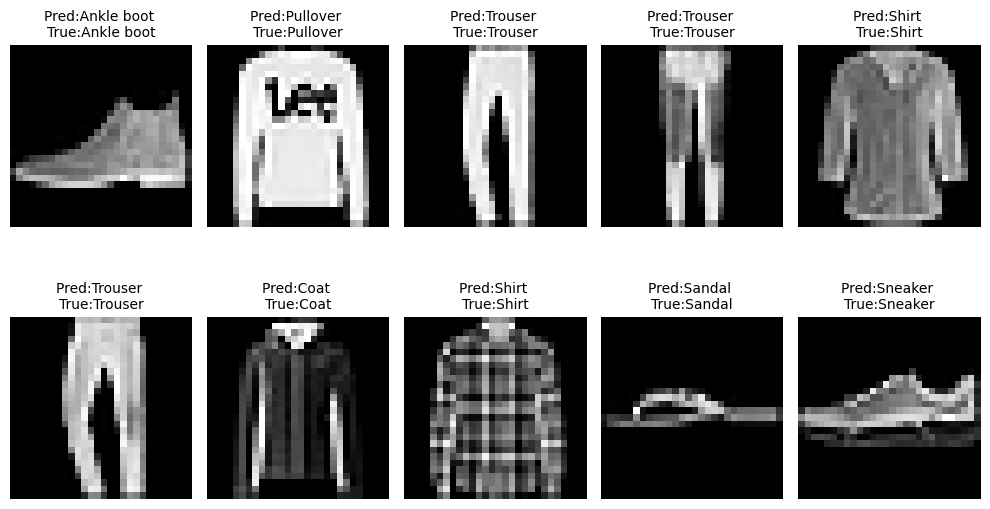

In [ ]:
predictions = model.predict(x_test)

plt.figure(figsize=(10, 6))

for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    pred_label = np.argmax(predictions[i])
    true_label = y_test[i]
    plt.title(f"Pred:{idx_to_label[pred_label]} \nTrue:{idx_to_label[true_label]}",
              fontsize=10
    )
    plt.axis('off')

plt.tight_layout()
plt.show()

## 📊 10. Evaluate Model

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8686 - loss: 0.3959
Test Accuracy: 0.8686000108718872


In [ ]:
y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)


print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

📊 Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.77      0.81      1000
           1       1.00      0.94      0.97      1000
           2       0.85      0.70      0.77      1000
           3       0.83      0.92      0.87      1000
           4       0.82      0.74      0.77      1000
           5       0.96      0.97      0.97      1000
           6       0.59      0.79      0.68      1000
           7       0.96      0.92      0.94      1000
           8       0.98      0.96      0.97      1000
           9       0.95      0.97      0.96      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



## 11. Error Analysis

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


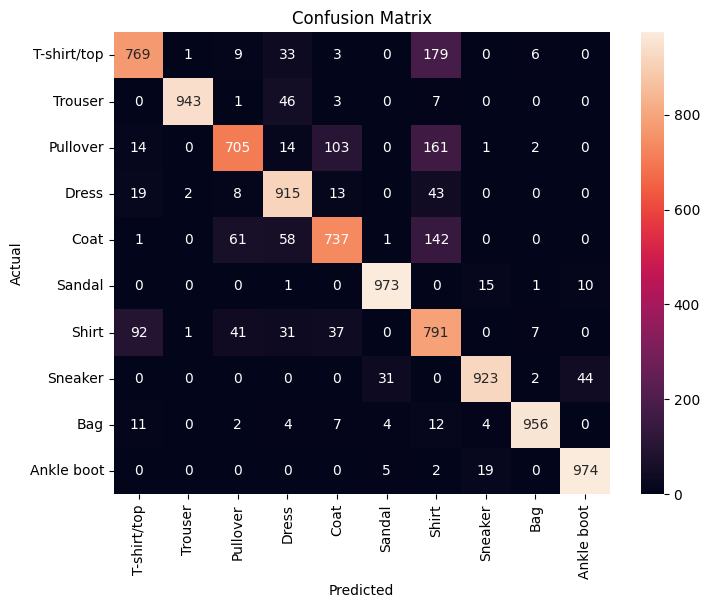

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)


cm = confusion_matrix(
    y_test,
    y_pred
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=idx_to_label.values(),
    yticklabels=idx_to_label.values()
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Total errors: 1314


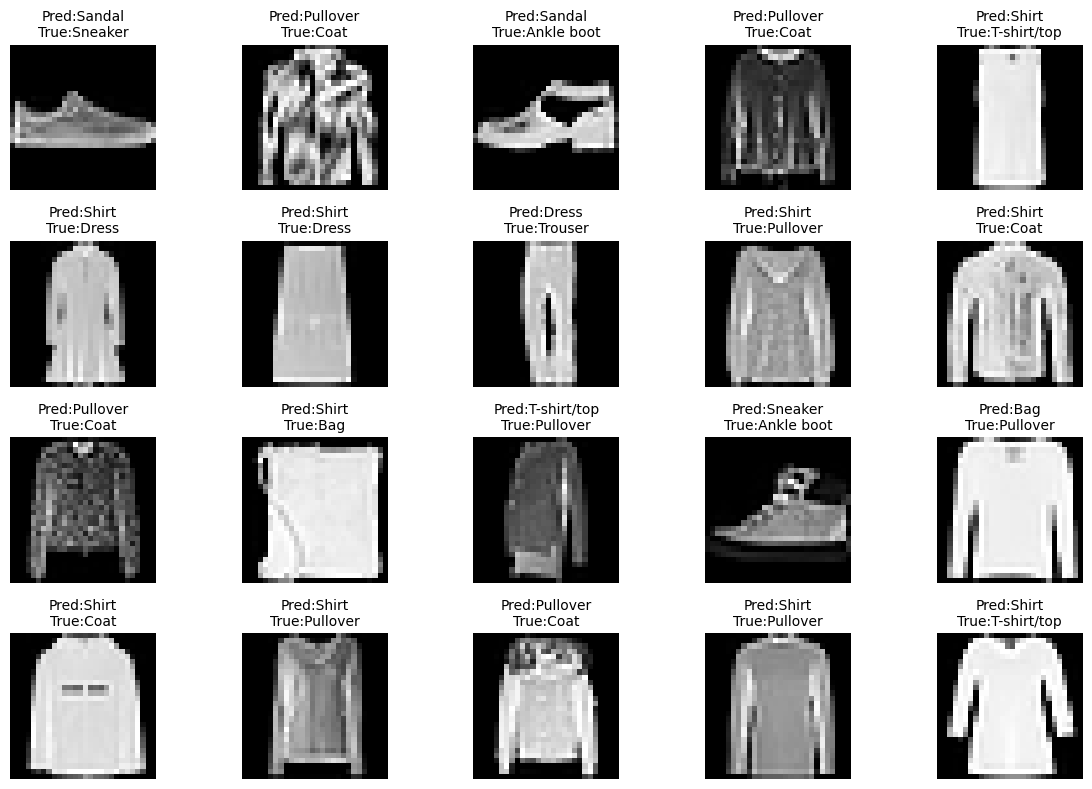

In [ ]:
# Get predictions
predictions = model.predict(x_test)

# Convert probabilities to labels
pred_labels = np.argmax(predictions, axis=1)


# Find wrong predictions
errors = np.where(pred_labels != y_test)[0]


print("Total errors:", len(errors))


# Visualize wrong predictions
plt.figure(figsize=(12, 8))

for i, idx in enumerate(errors[:20]):   # show first 20 mistakes

    plt.subplot(4, 5, i+1)

    plt.imshow(
        x_test[idx].reshape(28,28),
        cmap='gray'
    )

    pred_label = pred_labels[idx]
    true_label = y_test[idx]

    plt.title(
        f"Pred:{idx_to_label[pred_label]}\nTrue:{idx_to_label[true_label]}",
        fontsize=10
    )

    plt.axis('off')


plt.tight_layout()
plt.show()

## 12. Saving the Model

In [ ]:
model_name = "ann_fashion_mnist_with_batchnorm.h5"

model.save(model_name)


In [ ]:
loaded_model = tf.keras.models.load_model(model_name)
print("Model loaded successfully!")

Model loaded successfully!
